# Uniform Distribution

The **Uniform distribution** assigns equal probability to every point in an interval $[A, B]$. It is the simplest continuous distribution and is the foundation for random number generation — almost all RNGs produce $\text{Uniform}(0,1)$ values from which all other distributions are derived.

| Property | Value |
|---|---|
| **Parameters** | $A$ (lower bound), $B$ (upper bound), $A < B$ |
| **Support** | $[A,\, B]$ |
| **PDF** | $\displaystyle f(x) = \frac{1}{B - A} \quad \text{for } A \le x \le B,\; \text{else } 0$ |
| **CDF** | $\displaystyle F(x) = \frac{x - A}{B - A}$ |
| **Mean** | $\dfrac{A + B}{2}$ |
| **Median** | $\dfrac{A + B}{2}$ |
| **Std Dev** | $\dfrac{B - A}{\sqrt{12}}$ |
| **Skewness** | $0$ (symmetric) |
| **Kurtosis** | $\dfrac{9}{5} = 1.8$ (platykurtic — flatter than Normal) |
| **Parameter estimation** | $\hat{A} = \min(x),\quad \hat{B} = \max(x)$ |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import SVG, display
import warnings
warnings.filterwarnings('ignore')

## Visualising the Uniform Distribution

### Probability Density Function (PDF)

The PDF of the Uniform distribution is a **flat rectangle** of constant height:

$$f(x) = \frac{1}{B - A}, \quad A \le x \le B$$

- Every value in $[A, B]$ is equally likely — there is no peak or preferred region.
- A wider interval $[A, B]$ produces a shorter rectangle (lower density) so the total area stays $1$.
- Outside $[A, B]$ the density is exactly $0$.

---

### Cumulative Distribution Function (CDF)

The CDF is a **linear ramp** from $0$ to $1$:

$$F(x) = \frac{x - A}{B - A}, \quad A \le x \le B$$

- Probability accumulates at a **constant rate** across the support.
- The slope of the ramp equals $\tfrac{1}{B-A}$, which is also the PDF height.

---

### Probability Integral Transform

The third panel illustrates the **inverse CDF (quantile) method**: if $U \sim \text{Uniform}(0,1)$ then $F^{-1}(U)$ follows any target distribution $F$. Here $X = -\ln(U) \sim \text{Exponential}(1)$, showing how every distribution can be sampled from a uniform RNG.


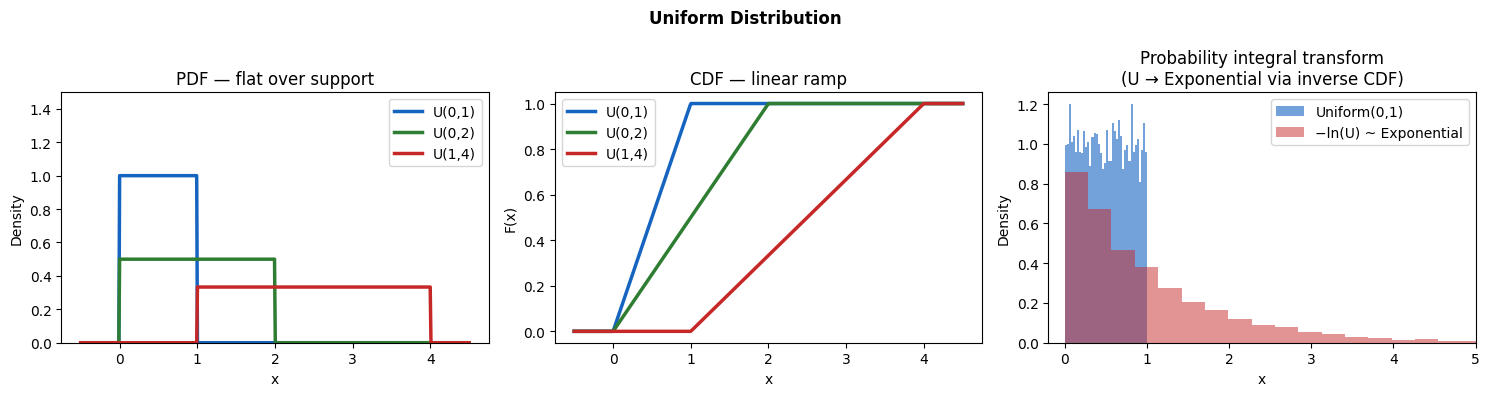

U(0,1): mean=0.500, std=0.289, skewness=0, kurtosis=1.8


In [2]:
x = np.linspace(-0.5, 4.5, 500)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Uniform Distribution', fontsize=12, fontweight='bold')

# PDF — different intervals
for A, B, color, label in [(0, 1, '#1565C0', 'U(0,1)'),
                             (0, 2, '#2E7D32', 'U(0,2)'),
                             (1, 4, '#C62828', 'U(1,4)')]:
    dist = stats.uniform(loc=A, scale=B-A)
    axes[0].plot(x, dist.pdf(x), color=color, linewidth=2.5, label=label)
axes[0].set_title('PDF — flat over support')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].set_ylim(0, 1.5)
axes[0].legend()

# CDF
for A, B, color, label in [(0, 1, '#1565C0', 'U(0,1)'),
                             (0, 2, '#2E7D32', 'U(0,2)'),
                             (1, 4, '#C62828', 'U(1,4)')]:
    dist = stats.uniform(loc=A, scale=B-A)
    axes[1].plot(x, dist.cdf(x), color=color, linewidth=2.5, label=label)
axes[1].set_title('CDF — linear ramp')
axes[1].set_xlabel('x'); axes[1].set_ylabel('F(x)')
axes[1].legend()

# Probability integral transform: U(0,1) → any distribution
np.random.seed(42)
u = np.random.uniform(0, 1, 5000)
# Transform to exponential via inverse CDF: X = -ln(U)
exp_sample = -np.log(u)
axes[2].hist(u, bins=40, density=True, alpha=0.6, color='#1565C0', label='Uniform(0,1)')
axes[2].hist(exp_sample, bins=40, density=True, alpha=0.5, color='#C62828', label='−ln(U) ~ Exponential')
axes[2].set_title('Probability integral transform\n(U → Exponential via inverse CDF)')
axes[2].set_xlabel('x'); axes[2].set_ylabel('Density')
axes[2].set_xlim(-0.2, 5)
axes[2].legend()

plt.tight_layout()
plt.show()

# Summary stats
A, B = 0, 1
print(f"U({A},{B}): mean={(A+B)/2:.3f}, std={(B-A)/np.sqrt(12):.3f}, skewness=0, kurtosis=1.8")

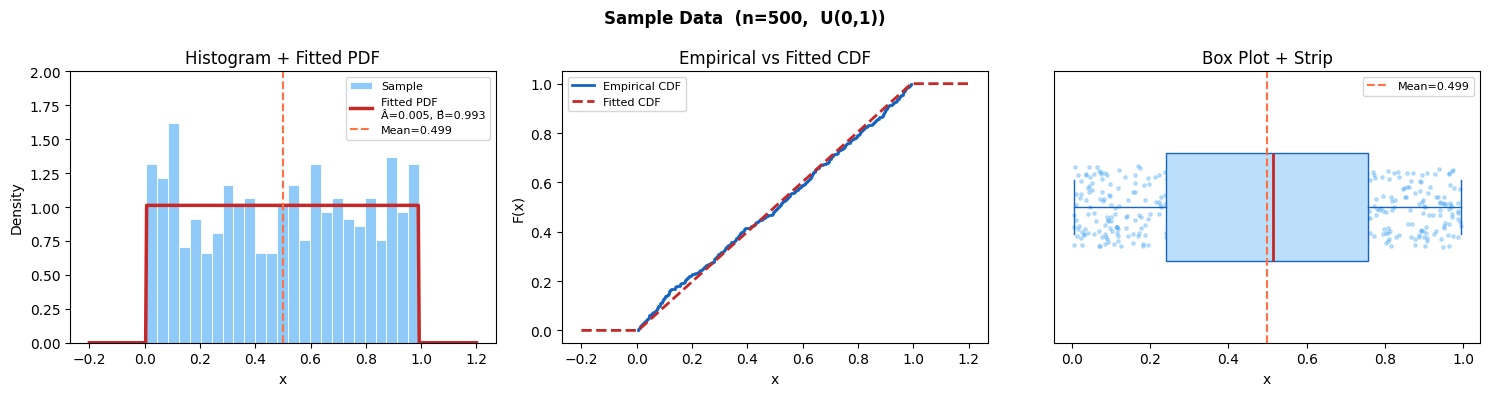

Sample statistics:  n=500  mean=0.4986  std=0.2987  skew=-0.0255  kurtosis=-1.2549


In [3]:
# Sample data plots — Uniform(0, 1) sample
np.random.seed(42)
sample_u = np.random.uniform(0, 1, 500)
A_hat, B_hat = sample_u.min(), sample_u.max()
x_fit = np.linspace(-0.2, 1.2, 400)
dist_fit = stats.uniform(loc=A_hat, scale=B_hat - A_hat)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Sample Data  (n=500,  U(0,1))', fontsize=12, fontweight='bold')

# ── Histogram + fitted PDF ───────────────────────────────────────────────────
axes[0].hist(sample_u, bins=25, density=True,
             color='#90CAF9', edgecolor='white', linewidth=0.6, label='Sample')
axes[0].plot(x_fit, dist_fit.pdf(x_fit),
             color='#C62828', linewidth=2.5, label=f'Fitted PDF\nÂ={A_hat:.3f}, B̂={B_hat:.3f}')
axes[0].axvline(sample_u.mean(), color='#FF7043', linewidth=1.5, linestyle='--',
                label=f'Mean={sample_u.mean():.3f}')
axes[0].set_title('Histogram + Fitted PDF')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].set_ylim(0, 2)
axes[0].legend(fontsize=8)

# ── Empirical CDF vs theoretical CDF ────────────────────────────────────────
sorted_s = np.sort(sample_u)
ecdf = np.arange(1, len(sorted_s) + 1) / len(sorted_s)
axes[1].step(sorted_s, ecdf, color='#1565C0', linewidth=2, label='Empirical CDF')
axes[1].plot(x_fit, dist_fit.cdf(x_fit),
             color='#C62828', linewidth=2, linestyle='--', label='Fitted CDF')
axes[1].set_title('Empirical vs Fitted CDF')
axes[1].set_xlabel('x'); axes[1].set_ylabel('F(x)')
axes[1].legend(fontsize=8)

# ── Box plot + strip ─────────────────────────────────────────────────────────
axes[2].boxplot(sample_u, vert=False, patch_artist=True, widths=0.4,
                boxprops=dict(facecolor='#BBDEFB', color='#1565C0'),
                medianprops=dict(color='#C62828', linewidth=2),
                whiskerprops=dict(color='#1565C0'),
                capprops=dict(color='#1565C0'),
                flierprops=dict(marker='o', color='#FF7043', markersize=4, alpha=0.6))
axes[2].scatter(sample_u, np.random.uniform(0.85, 1.15, len(sample_u)),
                color='#42A5F5', s=6, alpha=0.3)
axes[2].axvline(sample_u.mean(), color='#FF7043', linewidth=1.5, linestyle='--',
                label=f'Mean={sample_u.mean():.3f}')
axes[2].set_title('Box Plot + Strip')
axes[2].set_xlabel('x'); axes[2].set_yticks([])
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Sample statistics:  n={len(sample_u)}  mean={sample_u.mean():.4f}"
      f"  std={sample_u.std(ddof=1):.4f}"
      f"  skew={stats.skew(sample_u):.4f}  kurtosis={stats.kurtosis(sample_u):.4f}")


## Key Takeaways

| | |
|---|---|
| **Shape** | Flat rectangle — equal probability everywhere in $[A, B]$ |
| **Kurtosis** | $1.8 < 3$ (platykurtic — lighter tails than Normal) |
| **RNG foundation** | All distributions derived from $U(0,1)$ via inverse CDF transform |
| **Probability integral transform** | If $X \sim F$, then $F(X) \sim U(0,1)$; conversely $X = F^{-1}(U)$ |
| **Estimation** | $\hat{A} = \min(\text{sample}),\quad \hat{B} = \max(\text{sample})$ (MLE) |
| **Use cases** | Prior in Bayesian analysis (uninformative), simulation, rounding error models |
